# EDA — Hey Banco Datathon 2026

Análisis exploratorio de los 3 datasets de Hey Banco **manejados por separado**.

**Estructura del notebook:**
1. Setup + funciones reutilizables
2. Carga de los 3 datasets
3. Para cada dataset (clientes, productos, transacciones):
   - Inventario de variables
   - Missing values
   - Duplicados
   - Calidad categórica (typos, codificación)
   - Distribuciones numéricas + outliers
   - Visualizaciones priorizando efectividad
   - Correlaciones (numéricas y categóricas)
4. Resumen ejecutivo de hallazgos

**Convención de paths:** los CSVs están en `../data/`.

---
## 1. Setup

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Estética
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

# Mostrar más en pandas
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print('Setup listo.')

Setup listo.


### 1.1 Funciones reutilizables

Estas funciones se aplican a cualquier dataset. Evitan duplicar código en las 3 secciones.

In [47]:
def inventario_variables(df: pd.DataFrame, nombre: str = '') -> pd.DataFrame:
    """
    Inventario completo de variables: tipo, nulls, únicos, ejemplos.
    Incluye una clasificación heurística (numérica continua / discreta / categórica / texto).
    """
    n = len(df)
    out = []
    for col in df.columns:
        s = df[col]
        n_null = s.isna().sum()
        n_unique = s.nunique(dropna=True)
        dtype = str(s.dtype)

        # Clasificación heurística
        if pd.api.types.is_bool_dtype(s):
            tipo_log = 'booleana'
        elif pd.api.types.is_numeric_dtype(s):
            tipo_log = 'numérica_discreta' if n_unique < 30 else 'numérica_continua'
        elif pd.api.types.is_datetime64_any_dtype(s):
            tipo_log = 'temporal'
        else:
            # Heurística texto vs categórica: si la moda repite mucho y hay pocos únicos -> categórica
            ratio_unicos = n_unique / max(n - n_null, 1)
            if ratio_unicos < 0.05 or n_unique < 50:
                tipo_log = 'categórica'
            else:
                tipo_log = 'texto_libre' if s.dropna().astype(str).str.len().mean() > 15 else 'identificador'

        out.append({
            'variable': col,
            'dtype': dtype,
            'tipo_logico': tipo_log,
            'n_null': n_null,
            'pct_null': round(100 * n_null / n, 2),
            'n_unique': n_unique,
            'ejemplos': s.dropna().unique()[:3].tolist() if n_unique > 0 else []
        })
    inv = pd.DataFrame(out)
    if nombre:
        print(f'\n📋 Inventario — {nombre} ({n:,} filas, {df.shape[1]} columnas)')
    return inv


def reporte_missing(df: pd.DataFrame, nombre: str = '') -> None:
    """Visualiza missingness y devuelve tabla."""
    miss = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        print(f'✅ {nombre}: sin valores faltantes.')
        return
    fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(miss))))
    miss.plot(kind='barh', ax=ax, color='#E63946')
    ax.set_xlabel('% faltante')
    ax.set_title(f'Valores faltantes — {nombre}')
    ax.invert_yaxis()
    for i, v in enumerate(miss.values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()


def reporte_duplicados(df: pd.DataFrame, nombre: str, key_cols: list = None) -> None:
    """Detecta duplicados completos y, si se da una llave esperada, duplicados por esa llave."""
    full_dup = df.duplicated().sum()
    print(f'🔁 {nombre}: {full_dup:,} filas completamente duplicadas '
          f'({100*full_dup/len(df):.2f}%)')
    if key_cols:
        key_dup = df.duplicated(subset=key_cols).sum()
        print(f'   Duplicados por {key_cols}: {key_dup:,}')
        if key_dup > 0:
            ejemplos = df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols).head(6)
            print('   Ejemplos:')
            display(ejemplos)


def diagnostico_categoricas(df: pd.DataFrame, cols: list, nombre: str = '') -> None:
    """
    Detecta problemas comunes en categóricas:
    - espacios al inicio/fin
    - mayúsculas/minúsculas inconsistentes
    - acentos / no-acentos del mismo valor
    - cardinalidad sospechosa
    """
    print(f'\n🔎 Diagnóstico de calidad en categóricas — {nombre}')
    for col in cols:
        s = df[col].dropna().astype(str)
        if s.empty:
            continue
        problemas = []
        if (s != s.str.strip()).any():
            problemas.append('espacios extremos')
        if s.str.lower().nunique() < s.nunique():
            problemas.append('mayúsculas/minúsculas inconsistentes')
        # Ver si hay versiones con/sin acento del mismo valor
        norm = s.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('ascii').str.lower()
        if norm.nunique() < s.str.lower().nunique():
            problemas.append('acentos inconsistentes')
        flag = '⚠️' if problemas else '✅'
        print(f'  {flag} {col}: {s.nunique()} valores únicos. {", ".join(problemas) if problemas else "OK"}')


def detectar_outliers(serie: pd.Series, metodo: str = 'iqr') -> dict:
    """Detecta outliers por IQR o Z-score. Devuelve dict con lower, upper, n_outliers, pct."""
    s = serie.dropna()
    if len(s) == 0 or not pd.api.types.is_numeric_dtype(s):
        return {}
    if metodo == 'iqr':
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out = ((s < lower) | (s > upper)).sum()
    else:  # z-score
        z = np.abs(stats.zscore(s, nan_policy='omit'))
        lower, upper = s.mean() - 3 * s.std(), s.mean() + 3 * s.std()
        out = (z > 3).sum()
    return {
        'lower': float(lower), 'upper': float(upper),
        'n_outliers': int(out), 'pct_outliers': round(100 * out / len(s), 2)
    }


def diagnostico_distribucion(serie: pd.Series) -> str:
    """
    Etiqueta tentativa de la distribución basada en skewness y kurtosis.
    No es un test formal, es una pista heurística.
    """
    s = serie.dropna()
    if len(s) < 30 or not pd.api.types.is_numeric_dtype(s):
        return 'n/a'
    sk, kt = s.skew(), s.kurt()
    if abs(sk) < 0.5 and abs(kt) < 1:
        return 'aprox. normal'
    if sk > 1.5:
        return 'log-normal / sesgo derecho fuerte'
    if sk > 0.5:
        return 'sesgo derecho moderado'
    if sk < -1.5:
        return 'sesgo izquierdo fuerte'
    if sk < -0.5:
        return 'sesgo izquierdo moderado'
    if kt < -1:
        return 'aprox. uniforme / bimodal'
    return 'mixta'


def perfil_numericas(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Tabla con stats robustos + outliers + dx de distribución para cada numérica."""
    rows = []
    for c in cols:
        if c not in df.columns or not pd.api.types.is_numeric_dtype(df[c]):
            continue
        s = df[c]
        out = detectar_outliers(s, 'iqr')
        rows.append({
            'variable': c,
            'min': s.min(), 'p25': s.quantile(0.25), 'mediana': s.median(),
            'media': s.mean(), 'p75': s.quantile(0.75), 'max': s.max(),
            'std': s.std(), 'skew': s.skew(), 'kurtosis': s.kurt(),
            'pct_outliers_iqr': out.get('pct_outliers', np.nan),
            'distribucion': diagnostico_distribucion(s)
        })
    return pd.DataFrame(rows)


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Cramér's V con corrección de bias (Bergsma) para asociación entre 2 categóricas."""
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.values.sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan


def matriz_cramers_v(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Matriz simétrica de Cramér's V para una lista de categóricas."""
    m = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
    for a, b in combinations(cols, 2):
        v = cramers_v(df[a], df[b])
        m.loc[a, b] = v
        m.loc[b, a] = v
    return m


def correlation_ratio(categorical: pd.Series, numerical: pd.Series) -> float:
    """η (correlation ratio) — asociación categórica → numérica. Rango [0,1]."""
    df_ = pd.DataFrame({'cat': categorical, 'num': numerical}).dropna()
    if df_.empty or df_['cat'].nunique() < 2:
        return np.nan
    grand_mean = df_['num'].mean()
    ss_between = df_.groupby('cat')['num'].apply(
        lambda g: len(g) * (g.mean() - grand_mean) ** 2
    ).sum()
    ss_total = ((df_['num'] - grand_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan


print('Funciones cargadas.')

Funciones cargadas.


---
## 2. Carga de los 3 datasets

In [48]:
DATA_DIR = '../data'

df_clientes = pd.read_csv(f'{DATA_DIR}/hey_clientes.csv')
df_productos = pd.read_csv(f'{DATA_DIR}/hey_productos.csv', parse_dates=['fecha_apertura', 'fecha_ultimo_movimiento'])
df_transacciones = pd.read_csv(f'{DATA_DIR}/hey_transacciones.csv', parse_dates=['fecha_hora'])

print(f'Clientes:       {df_clientes.shape}')
print(f'Productos:      {df_productos.shape}')
print(f'Transacciones:  {df_transacciones.shape}')

print(f'\nMemoria total: {(df_clientes.memory_usage(deep=True).sum() + df_productos.memory_usage(deep=True).sum() + df_transacciones.memory_usage(deep=True).sum()) / 1e6:.1f} MB')

Clientes:       (15025, 22)
Productos:      (38909, 13)
Transacciones:  (802384, 22)

Memoria total: 650.7 MB


In [49]:
# Primeras filas de cada uno, lado a lado
print('CLIENTES — head')
display(df_clientes.head(3))
print('\nPRODUCTOS — head')
display(df_productos.head(3))
print('\nTRANSACCIONES — head')
display(df_transacciones.head(3))

CLIENTES — head


,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,nomina_domiciliada,canal_apertura,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,False,App,527,1,app_android,10.0000,False,True,es_MX,False,2,False
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,False,App,714,3,app_android,8.0000,False,True,es_MX,True,2,False
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,False,App,454,3,app_ios,8.0000,False,True,es_MX,False,2,False



PRODUCTOS — head


,producto_id,user_id,tipo_producto,fecha_apertura,estatus,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,es_dato_sintetico
0,PRD-00000001,USR-00001,cuenta_debito,2023-06-26,activo,NaN,"80,954.6000",NaN,NaN,NaN,NaN,2025-11-27,True
1,PRD-00000002,USR-00001,tarjeta_credito_hey,2022-10-16,activo,"144,000.0000","88,790.4000",0.6166,35.7100,NaN,NaN,2025-09-17,True
2,PRD-00000003,USR-00002,cuenta_debito,2025-04-03,activo,NaN,"20,712.5400",NaN,NaN,NaN,NaN,2025-10-16,True



TRANSACCIONES — head


,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,estatus,motivo_no_procesada,intento_numero,meses_diferidos,cashback_generado,descripcion_libre,hora_del_dia,dia_semana,es_internacional,dispositivo,patron_uso_atipico,es_dato_sintetico
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.8800,DivertidoPark,entretenimiento,"Nueva York, NY",completada,NaN,1,NaN,0.3400,Cargo automático,14,Wednesday,True,app_ios,False,True
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.0000,GamerPass,servicios_digitales,CDMX - Benito Juárez,completada,NaN,1,NaN,NaN,Cargo automático,0,Friday,False,app_ios,False,True
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.0000,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,completada,NaN,1,NaN,NaN,inv hey,22,Friday,False,app_huawei,False,True


---
## 3. EDA por dataset (los tres en paralelo, separados)

Cada subsección sigue el mismo guion:
1. Inventario
2. Missing
3. Duplicados
4. Calidad categórica
5. Distribuciones numéricas + outliers
6. Visualizaciones clave
7. Correlaciones internas

---
### 3.A · `hey_clientes.csv`

In [50]:
# 3.A.1 Inventario
inv_cli = inventario_variables(df_clientes, 'clientes')
display(inv_cli)


📋 Inventario — clientes (15,025 filas, 22 columnas)


,variable,dtype,tipo_logico,n_null,pct_null,n_unique,ejemplos
0,user_id,str,identificador,0,0.0000,15025,"[USR-00001, USR-00002, USR-00003]"
1,edad,int64,numérica_continua,0,0.0000,43,"[21, 18, 23]"
2,sexo,str,categórica,0,0.0000,3,"[M, H, SE]"
3,estado,str,categórica,432,2.8800,17,"[Ciudad de México, Jalisco, Chihuahua]"
4,ciudad,str,categórica,432,2.8800,83,"[CDMX - Benito Juárez, Puerto Vallarta, Cuauht..."
5,nivel_educativo,str,categórica,0,0.0000,4,"[Preparatoria, Licenciatura, Posgrado]"
6,ocupacion,str,categórica,0,0.0000,6,"[Empleado, Estudiante, Empresario]"
7,ingreso_mensual_mxn,int64,numérica_continua,0,0.0000,151,"[24500, 19000, 14000]"
8,antiguedad_dias,int64,numérica_continua,0,0.0000,1816,"[1554, 1410, 1174]"
9,es_hey_pro,bool,booleana,0,0.0000,2,"[True, False]"


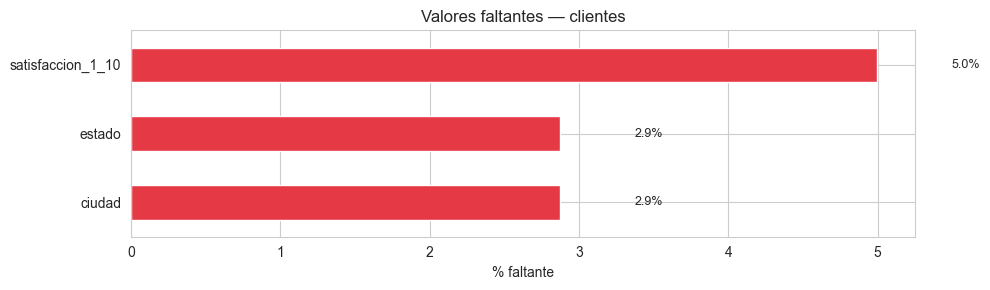

In [51]:
# 3.A.2 Missing
reporte_missing(df_clientes, 'clientes')

In [52]:
# 3.A.3 Duplicados
reporte_duplicados(df_clientes, 'clientes', key_cols=['user_id'])

🔁 clientes: 0 filas completamente duplicadas (0.00%)
   Duplicados por ['user_id']: 0


In [53]:
# 3.A.4 Calidad categórica
cat_cli = ['sexo', 'estado', 'ciudad', 'nivel_educativo', 'ocupacion', 'canal_apertura', 'preferencia_canal', 'idioma_preferido']
diagnostico_categoricas(df_clientes, cat_cli, 'clientes')

print('\nDistribución de categóricas clave:')
for c in ['sexo', 'nivel_educativo', 'ocupacion', 'canal_apertura', 'idioma_preferido']:
    print(f'\n— {c} —')
    print(df_clientes[c].value_counts(dropna=False).to_string())


🔎 Diagnóstico de calidad en categóricas — clientes
  ✅ sexo: 3 valores únicos. OK
  ✅ estado: 17 valores únicos. OK
  ✅ ciudad: 83 valores únicos. OK
  ✅ nivel_educativo: 4 valores únicos. OK
  ✅ ocupacion: 6 valores únicos. OK
  ✅ canal_apertura: 2 valores únicos. OK
  ✅ preferencia_canal: 3 valores únicos. OK
  ✅ idioma_preferido: 2 valores únicos. OK

Distribución de categóricas clave:

— sexo —
sexo
M     7281
H     7157
SE     587

— nivel_educativo —
nivel_educativo
Licenciatura    6616
Preparatoria    4400
Posgrado        2515
Secundaria      1494

— ocupacion —
ocupacion
Empleado         8550
Independiente    3327
Empresario       1682
Estudiante        839
Desempleado       465
Jubilado          162

— canal_apertura —
canal_apertura
App         12189
Fan Shop     2836

— idioma_preferido —
idioma_preferido
es_MX    14544
en_US      481


In [54]:
# Validación contra el diccionario: ¿valores fuera de los permitidos?
esperados = {
    'sexo': {'M', 'H', 'SE'},
    'nivel_educativo': {'Secundaria', 'Preparatoria', 'Licenciatura', 'Posgrado'},
    'ocupacion': {'Empleado', 'Independiente', 'Estudiante', 'Empresario', 'Desempleado', 'Jubilado'},
    'canal_apertura': {'App', 'Fan Shop'},
    'preferencia_canal': {'app_ios', 'app_android', 'app_huawei'},
    'idioma_preferido': {'es_MX', 'en_US'},
}
print('🔍 Validación contra catálogo del diccionario (clientes):')
for col, ok in esperados.items():
    actual = set(df_clientes[col].dropna().unique())
    extras = actual - ok
    faltantes = ok - actual
    if extras or faltantes:
        print(f'  ⚠️ {col}: extras={extras}, no_observados={faltantes}')
    else:
        print(f'  ✅ {col}: alineado con diccionario')

🔍 Validación contra catálogo del diccionario (clientes):
  ✅ sexo: alineado con diccionario
  ✅ nivel_educativo: alineado con diccionario
  ✅ ocupacion: alineado con diccionario
  ✅ canal_apertura: alineado con diccionario
  ✅ preferencia_canal: alineado con diccionario
  ✅ idioma_preferido: alineado con diccionario


In [55]:
# 3.A.5 Numéricas: perfil + outliers
num_cli = ['edad', 'ingreso_mensual_mxn', 'antiguedad_dias', 'score_buro', 'dias_desde_ultimo_login', 'satisfaccion_1_10', 'num_productos_activos']
perfil_cli = perfil_numericas(df_clientes, num_cli)
display(perfil_cli)

,variable,min,p25,mediana,media,p75,max,std,skew,kurtosis,pct_outliers_iqr,distribucion
0,edad,18.0000,29.0000,36.0000,37.1878,45.0000,60.0000,10.1899,0.1947,-0.8370,0.0000,aprox. normal
1,ingreso_mensual_mxn,"4,500.0000","16,000.0000","24,000.0000","29,793.6772","37,000.0000","99,000.0000","19,171.1565",1.3035,1.3067,6.0900,sesgo derecho moderado
2,antiguedad_dias,7.0000,490.0000,942.0000,935.1071,"1,375.0000","1,825.0000",512.9585,-0.0164,-1.1907,0.0000,aprox. uniforme / bimodal
3,score_buro,295.0000,529.0000,631.0000,618.4516,719.0000,850.0000,127.1600,-0.3790,-0.5612,0.0000,aprox. normal
4,dias_desde_ultimo_login,0.0000,2.0000,7.0000,18.7688,15.0000,180.0000,35.3056,2.9474,7.9879,11.4400,log-normal / sesgo derecho fuerte
5,satisfaccion_1_10,3.0000,6.0000,8.0000,7.4753,9.0000,10.0000,1.8782,-0.4848,-0.4468,0.0000,aprox. normal
6,num_productos_activos,0.0000,1.0000,2.0000,2.2328,3.0000,5.0000,1.1433,0.1196,-0.4703,0.0000,aprox. normal


In [56]:
# Validación de rangos contra diccionario
rangos = {
    'score_buro': (295, 850),
    'dias_desde_ultimo_login': (0, 180),
    'satisfaccion_1_10': (3, 10),
}
print('🔍 Rangos esperados vs observados (clientes):')
for col, (lo, hi) in rangos.items():
    s = df_clientes[col]
    fuera = ((s < lo) | (s > hi)).sum()
    print(f'  {col}: rango_obs=[{s.min()}, {s.max()}], esperado=[{lo}, {hi}], fuera_de_rango={fuera}')

🔍 Rangos esperados vs observados (clientes):
  score_buro: rango_obs=[295, 850], esperado=[295, 850], fuera_de_rango=0
  dias_desde_ultimo_login: rango_obs=[0, 180], esperado=[0, 180], fuera_de_rango=0
  satisfaccion_1_10: rango_obs=[3.0, 10.0], esperado=[3, 10], fuera_de_rango=0


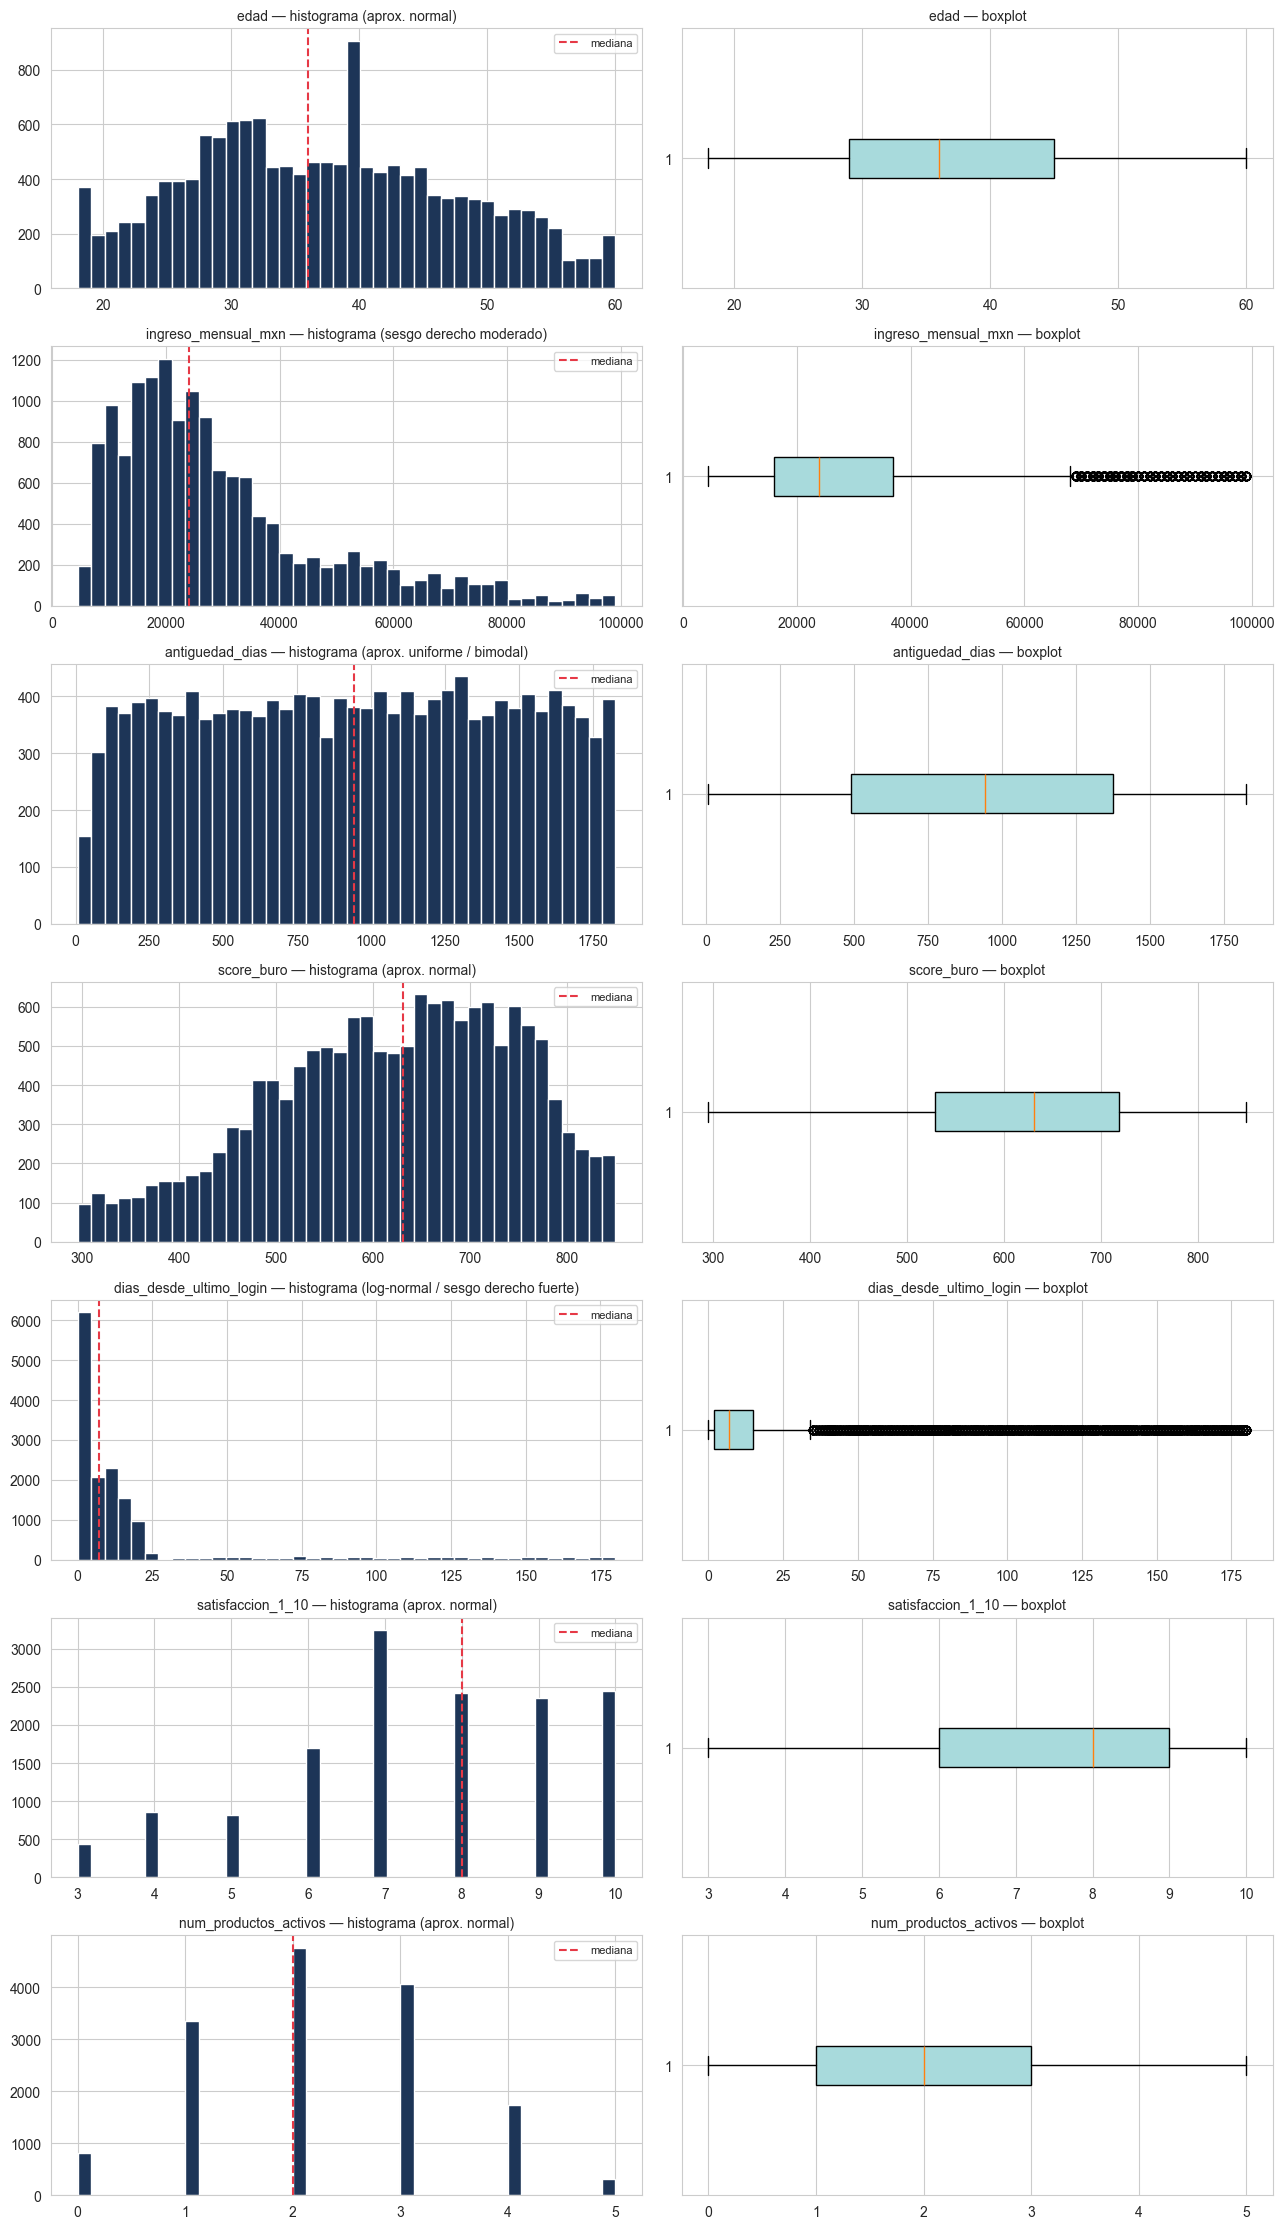

In [57]:
# 3.A.6 Visualizaciones — numéricas (histogramas + boxplots juntos)
fig, axes = plt.subplots(len(num_cli), 2, figsize=(13, 3.2 * len(num_cli)))
for i, c in enumerate(num_cli):
    axes[i, 0].hist(df_clientes[c].dropna(), bins=40, color='#1D3557', edgecolor='white')
    axes[i, 0].set_title(f'{c} — histograma ({diagnostico_distribucion(df_clientes[c])})', fontsize=10)
    axes[i, 0].axvline(df_clientes[c].median(), color='#E63946', linestyle='--', label='mediana')
    axes[i, 0].legend(fontsize=8)
    axes[i, 1].boxplot(df_clientes[c].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='#A8DADC'))
    axes[i, 1].set_title(f'{c} — boxplot', fontsize=10)
plt.tight_layout()
plt.show()

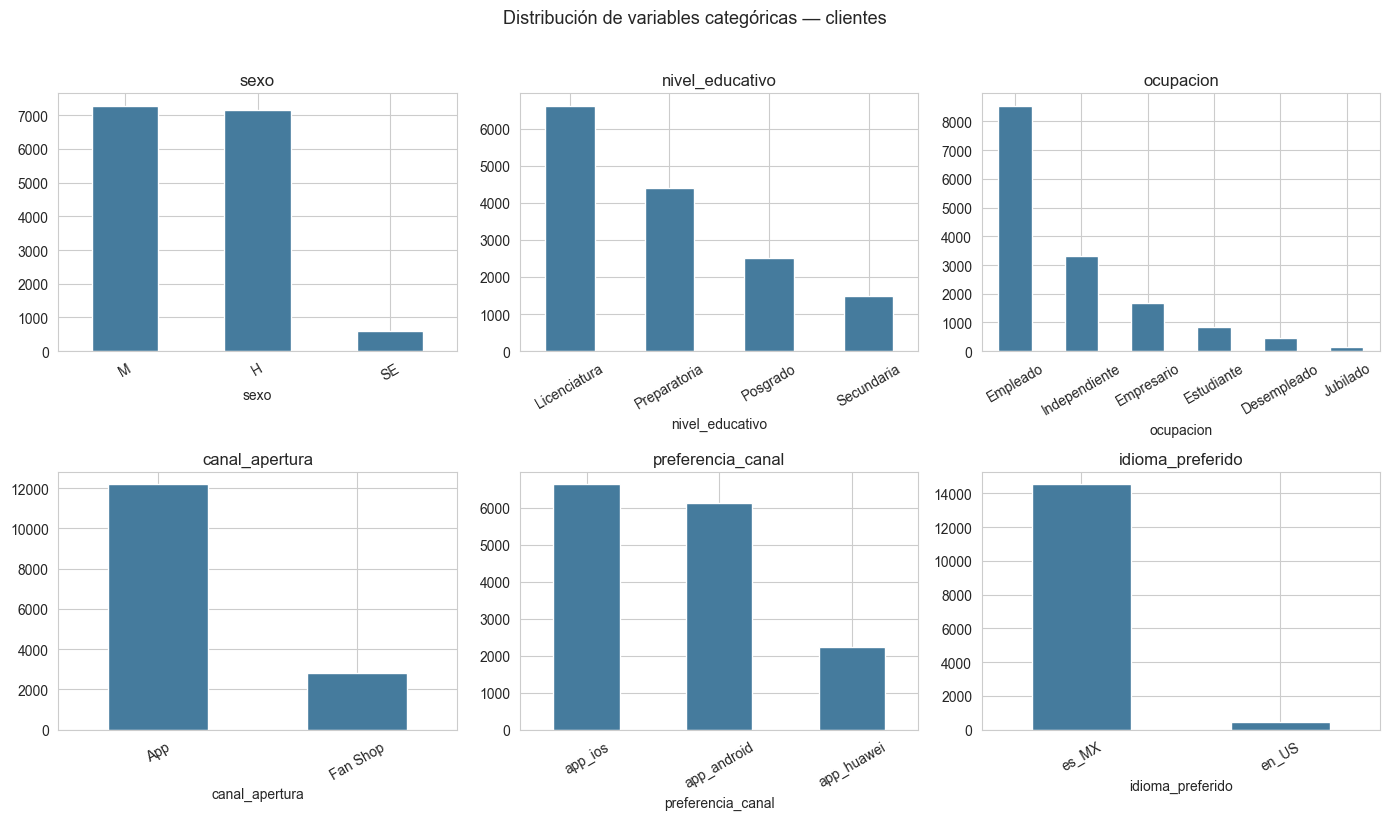

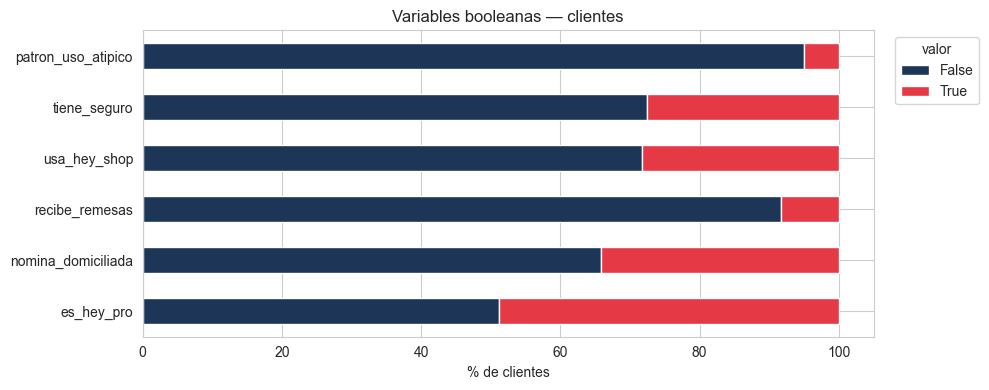

In [58]:
# 3.A.6b Visualizaciones — categóricas y booleanas
bool_cli = ['es_hey_pro', 'nomina_domiciliada', 'recibe_remesas', 'usa_hey_shop', 'tiene_seguro', 'patron_uso_atipico']
cat_plot = ['sexo', 'nivel_educativo', 'ocupacion', 'canal_apertura', 'preferencia_canal', 'idioma_preferido']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, c in zip(axes.flatten(), cat_plot):
    df_clientes[c].value_counts().plot(kind='bar', ax=ax, color='#457B9D', edgecolor='white')
    ax.set_title(c)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Distribución de variables categóricas — clientes', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Booleanas en una sola gráfica
bool_pct = pd.DataFrame({c: df_clientes[c].value_counts(normalize=True) * 100 for c in bool_cli}).T
fig, ax = plt.subplots(figsize=(10, 4))
bool_pct.plot(kind='barh', stacked=True, ax=ax, color=['#1D3557', '#E63946'], edgecolor='white')
ax.set_xlabel('% de clientes')
ax.set_title('Variables booleanas — clientes')
ax.legend(title='valor', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

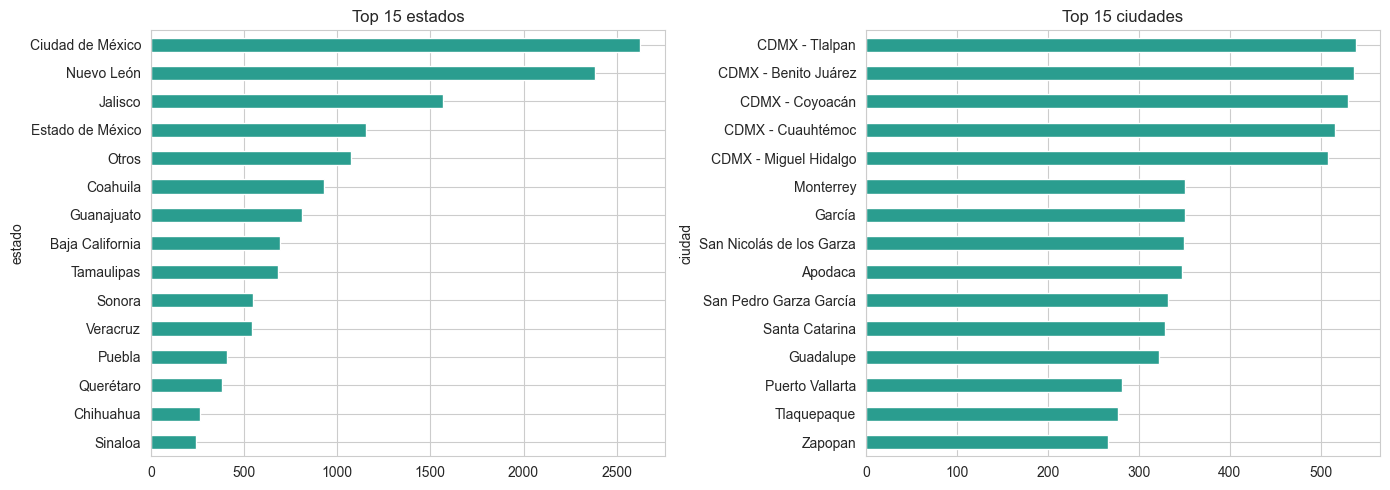

In [59]:
# 3.A.6c Geografía: top estados/ciudades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_clientes['estado'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='#2A9D8F')
axes[0].set_title('Top 15 estados')
axes[0].invert_yaxis()
df_clientes['ciudad'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='#2A9D8F')
axes[1].set_title('Top 15 ciudades')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

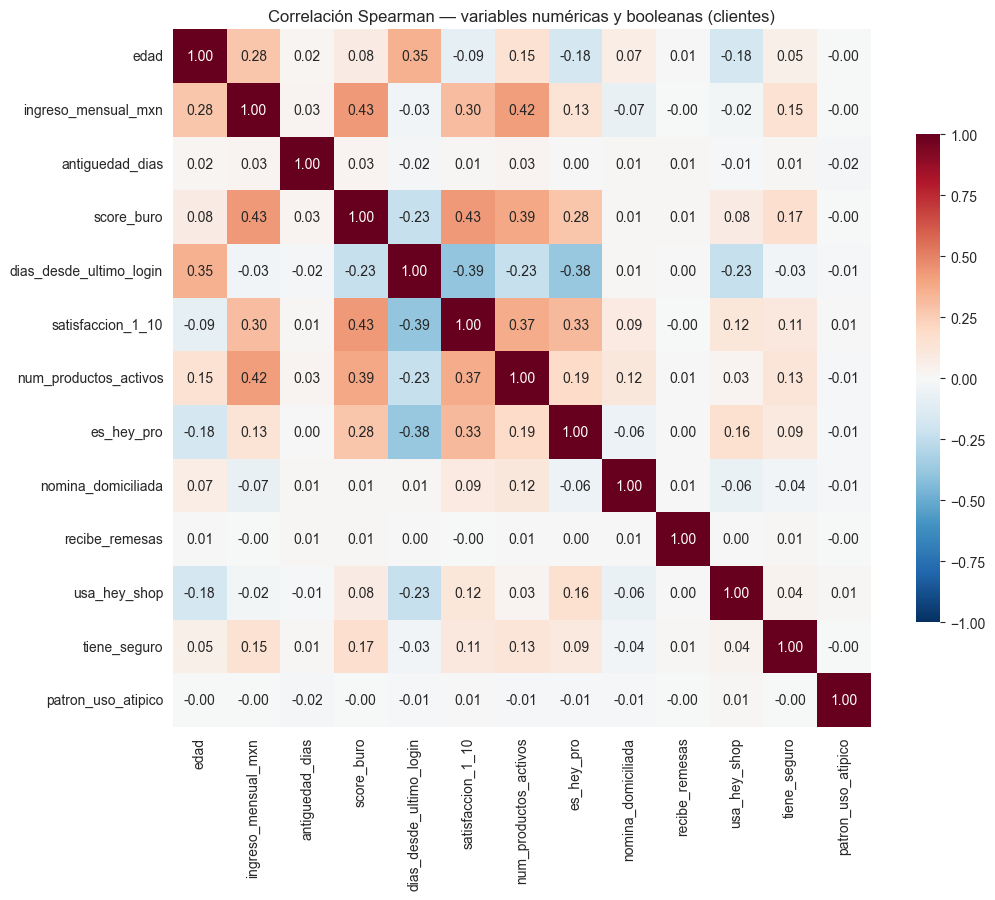

In [60]:
# 3.A.7 Correlaciones — clientes
# Numéricas vs numéricas (Spearman: robusto a no-normalidad)
num_for_corr = num_cli + ['es_hey_pro', 'nomina_domiciliada', 'recibe_remesas', 'usa_hey_shop', 'tiene_seguro', 'patron_uso_atipico']
df_corr = df_clientes[num_for_corr].astype(float)
corr = df_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax,
            square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Correlación Spearman — variables numéricas y booleanas (clientes)', fontsize=12)
plt.tight_layout()
plt.show()

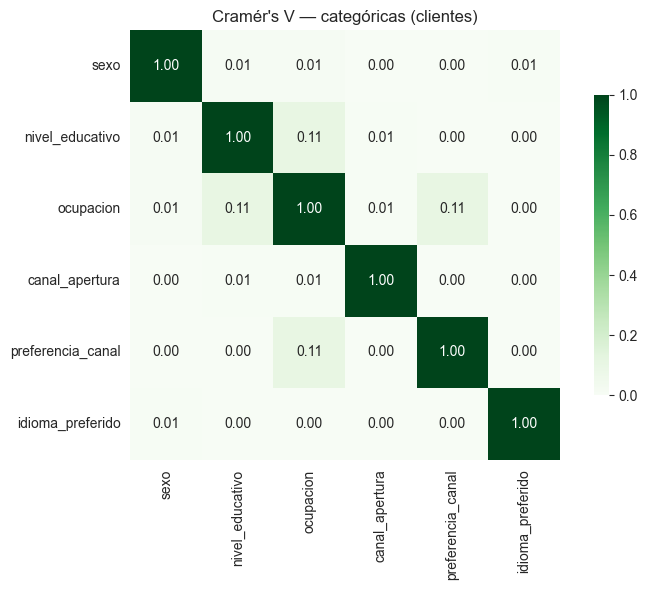

In [61]:
# Cramér's V — categóricas entre sí
cat_for_v = ['sexo', 'nivel_educativo', 'ocupacion', 'canal_apertura', 'preferencia_canal', 'idioma_preferido']
vmat = matriz_cramers_v(df_clientes, cat_for_v)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(vmat, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, square=True,
            cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title("Cramér's V — categóricas (clientes)", fontsize=12)
plt.tight_layout()
plt.show()

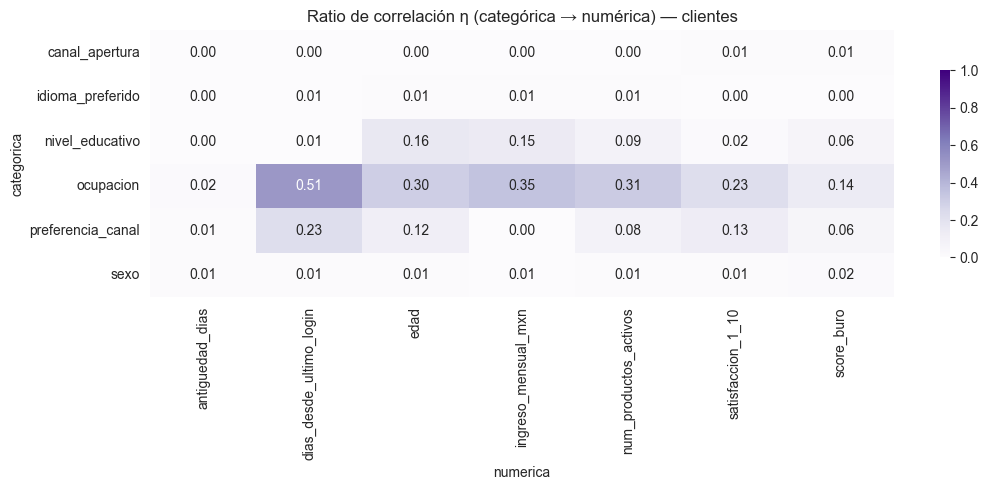

In [62]:
# Ratio de correlación: categórica → numérica (saca asociaciones tipo 'ocupación predice ingreso')
rows = []
for cat in cat_for_v:
    for num in num_cli:
        rows.append({
            'categorica': cat,
            'numerica': num,
            'eta': correlation_ratio(df_clientes[cat], df_clientes[num])
        })
eta_df = pd.DataFrame(rows).pivot(index='categorica', columns='numerica', values='eta')

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(eta_df, annot=True, fmt='.2f', cmap='Purples', vmin=0, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Ratio de correlación η (categórica → numérica) — clientes', fontsize=12)
plt.tight_layout()
plt.show()

---
### 3.B · `hey_productos.csv`

In [63]:
# 3.B.1 Inventario
inv_prod = inventario_variables(df_productos, 'productos')
display(inv_prod)


📋 Inventario — productos (38,909 filas, 13 columnas)


,variable,dtype,tipo_logico,n_null,pct_null,n_unique,ejemplos
0,producto_id,str,identificador,0,0.0000,38909,"[PRD-00000001, PRD-00000002, PRD-00000003]"
1,user_id,str,identificador,0,0.0000,15025,"[USR-00001, USR-00002, USR-00003]"
2,tipo_producto,str,categórica,0,0.0000,11,"[cuenta_debito, tarjeta_credito_hey, inversion..."
3,fecha_apertura,datetime64[us],temporal,0,0.0000,1733,"[2023-06-26 00:00:00, 2022-10-16 00:00:00, 202..."
4,estatus,str,categórica,0,0.0000,4,"[activo, cancelado, suspendido]"
5,limite_credito,float64,numérica_continua,24592,63.2000,490,"[144000.0, 22000.0, 5000.0]"
6,saldo_actual,float64,numérica_continua,3750,9.6400,34665,"[80954.6, 88790.4, 20712.54]"
7,utilizacion_pct,float64,numérica_continua,24592,63.2000,6791,"[0.6166, 0.2783, 0.3091]"
8,tasa_interes_anual,float64,numérica_continua,20118,51.7100,4782,"[35.71, 34.08, 39.88]"
9,plazo_meses,float64,numérica_discreta,34359,88.3100,7,"[12.0, 18.0, 6.0]"


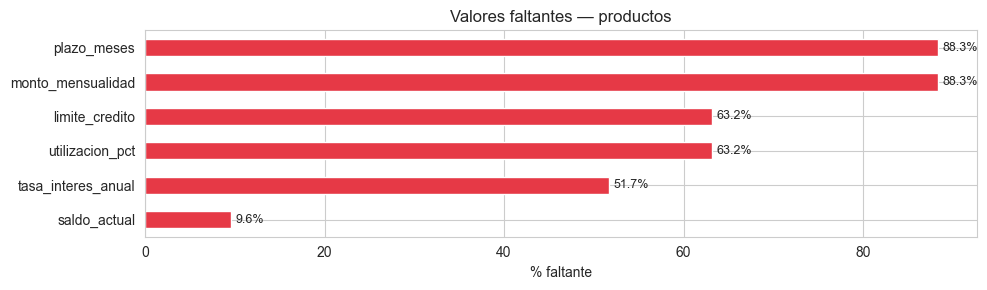


🔍 Coherencia de nulls vs tipo_producto:
  limite_credito: no-nulos en NO-crédito=0 (debe ser 0); nulos en crédito=0 (debe ser 0)
  utilizacion_pct: no-nulos en NO-crédito=0 (debe ser 0); nulos en crédito=0 (debe ser 0)


In [64]:
# 3.B.2 Missing — ojo: aquí los nulls son SEMÁNTICOS (productos sin crédito → null en limite_credito)
reporte_missing(df_productos, 'productos')

# Revisar coherencia: las variables crédito-only solo deben ser no-nulas en productos de crédito
print('\n🔍 Coherencia de nulls vs tipo_producto:')
credito_types = {'tarjeta_credito_hey', 'tarjeta_credito_garantizada', 'tarjeta_credito_negocios',
                 'credito_personal', 'credito_auto', 'credito_nomina'}
no_credito = df_productos[~df_productos['tipo_producto'].isin(credito_types)]
credito = df_productos[df_productos['tipo_producto'].isin(credito_types)]

for col in ['limite_credito', 'utilizacion_pct']:
    n_nc = no_credito[col].notna().sum()
    n_c = credito[col].isna().sum()
    print(f'  {col}: no-nulos en NO-crédito={n_nc} (debe ser 0); nulos en crédito={n_c} (debe ser 0)')

In [65]:
# 3.B.3 Duplicados
reporte_duplicados(df_productos, 'productos', key_cols=['producto_id'])

# Chequeo de integridad referencial con clientes
huerfanos = ~df_productos['user_id'].isin(df_clientes['user_id'])
print(f'\n🔗 Productos con user_id que NO existe en clientes: {huerfanos.sum():,}')

🔁 productos: 0 filas completamente duplicadas (0.00%)
   Duplicados por ['producto_id']: 0

🔗 Productos con user_id que NO existe en clientes: 0


In [66]:
# 3.B.4 Calidad categórica
cat_prod = ['tipo_producto', 'estatus']
diagnostico_categoricas(df_productos, cat_prod, 'productos')

print('\nDistribución:')
for c in cat_prod:
    print(f'\n— {c} —')
    print(df_productos[c].value_counts(dropna=False).to_string())


🔎 Diagnóstico de calidad en categóricas — productos
  ✅ tipo_producto: 11 valores únicos. OK
  ✅ estatus: 4 valores únicos. OK

Distribución:

— tipo_producto —
tipo_producto
cuenta_debito                  15025
tarjeta_credito_hey             7565
inversion_hey                   4474
seguro_vida                     2480
credito_nomina                  2044
credito_personal                1549
cuenta_negocios                 1343
seguro_compras                  1270
tarjeta_credito_negocios        1111
tarjeta_credito_garantizada     1091
credito_auto                     957

— estatus —
estatus
activo               33548
cancelado             2917
suspendido            1426
revision_de_pagos     1018


In [67]:
# 3.B.5 Numéricas
num_prod = ['limite_credito', 'saldo_actual', 'utilizacion_pct', 'tasa_interes_anual', 'plazo_meses', 'monto_mensualidad']
perfil_prod = perfil_numericas(df_productos, num_prod)
display(perfil_prod)

# Validación: utilizacion_pct ∈ [0,1]
fuera = ((df_productos['utilizacion_pct'] < 0) | (df_productos['utilizacion_pct'] > 1)).sum()
print(f'\n🔍 utilizacion_pct fuera de [0,1]: {fuera}')
# plazo_meses solo valores permitidos
plazos_ok = {6, 12, 18, 24, 36, 48, 60}
plazos_obs = set(df_productos['plazo_meses'].dropna().unique().astype(int))
print(f'plazo_meses fuera del catálogo: {plazos_obs - plazos_ok}')

,variable,min,p25,mediana,media,p75,max,std,skew,kurtosis,pct_outliers_iqr,distribucion
0,limite_credito,"1,000.0000","29,000.0000","64,000.0000","89,630.9283","111,000.0000","494,000.0000","94,668.4970",2.2816,5.3413,8.0000,log-normal / sesgo derecho fuerte
1,saldo_actual,100.9400,"15,596.2400","36,290.0900","60,007.0574","66,193.2650","499,905.5700","84,090.7280",3.1675,10.4952,8.2100,log-normal / sesgo derecho fuerte
2,utilizacion_pct,0.0501,0.2361,0.3700,0.4328,0.5762,1.0000,0.2504,0.6439,-0.6521,0.0000,sesgo derecho moderado
3,tasa_interes_anual,3.5000,14.6550,31.7400,29.1163,41.0600,66.9700,15.4839,-0.1676,-0.9326,0.0000,aprox. normal
4,plazo_meses,6.0000,12.0000,18.0000,23.0677,24.0000,60.0000,13.7514,1.0606,0.6092,10.7500,sesgo derecho moderado
5,monto_mensualidad,36.2900,738.2375,"1,477.3150","1,990.7032","2,784.1050","11,379.4200","1,683.1258",1.4242,2.0177,3.5800,sesgo derecho moderado



🔍 utilizacion_pct fuera de [0,1]: 0
plazo_meses fuera del catálogo: set()


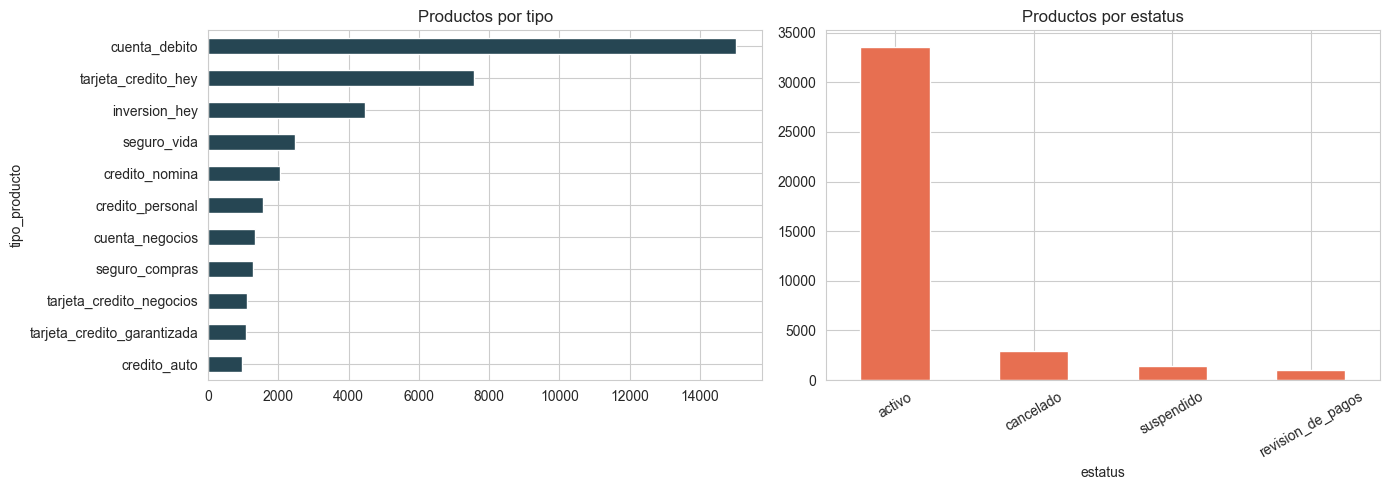

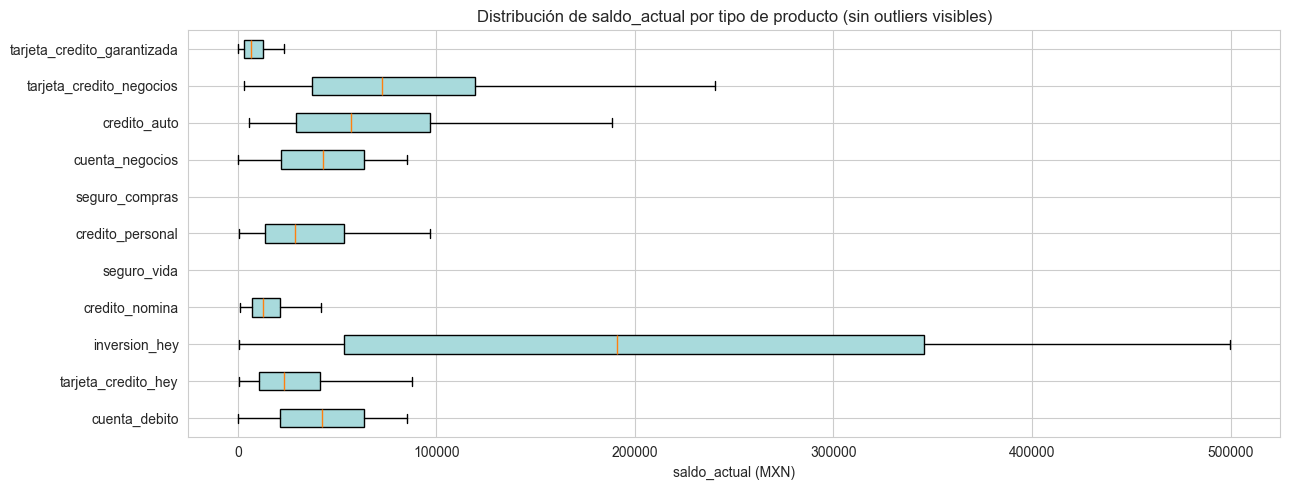

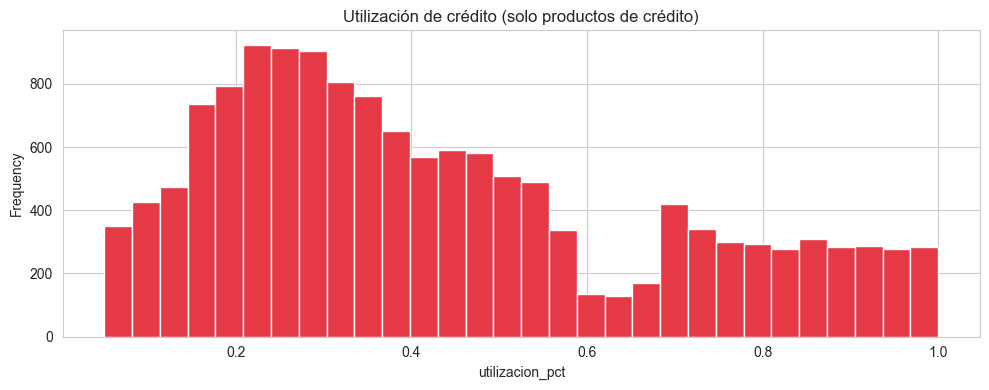

In [68]:
# 3.B.6 Visualización — productos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_productos['tipo_producto'].value_counts().plot(kind='barh', ax=axes[0], color='#264653')
axes[0].set_title('Productos por tipo')
axes[0].invert_yaxis()
df_productos['estatus'].value_counts().plot(kind='bar', ax=axes[1], color='#E76F51')
axes[1].set_title('Productos por estatus')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Distribuciones de saldo y utilización (por tipo de producto)
fig, ax = plt.subplots(figsize=(13, 5))
data = [df_productos.loc[df_productos['tipo_producto'] == t, 'saldo_actual'].dropna()
        for t in df_productos['tipo_producto'].unique()]
labels = list(df_productos['tipo_producto'].unique())
ax.boxplot(data, labels=labels, vert=False, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='#A8DADC'))
ax.set_title('Distribución de saldo_actual por tipo de producto (sin outliers visibles)')
ax.set_xlabel('saldo_actual (MXN)')
plt.tight_layout()
plt.show()

# Histograma de utilizacion_pct (solo créditos)
fig, ax = plt.subplots(figsize=(10, 4))
df_productos['utilizacion_pct'].dropna().plot(kind='hist', bins=30, ax=ax, color='#E63946', edgecolor='white')
ax.set_title('Utilización de crédito (solo productos de crédito)')
ax.set_xlabel('utilizacion_pct')
plt.tight_layout()
plt.show()

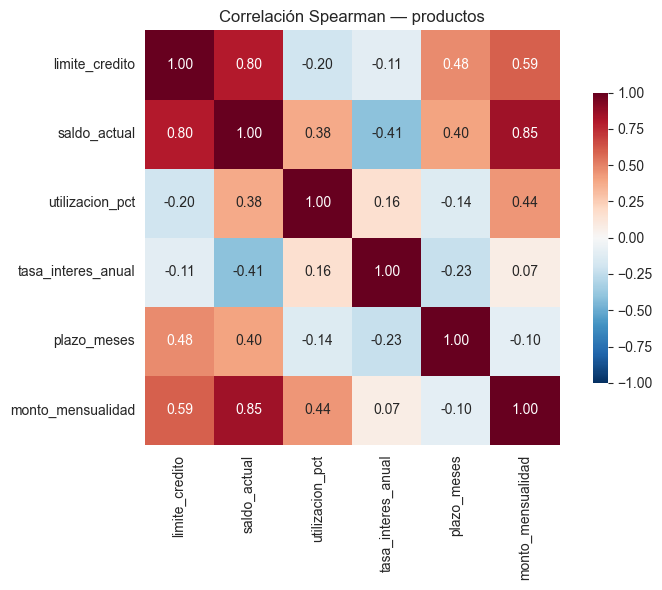

In [69]:
# 3.B.7 Correlaciones — productos (numéricas)
corr_prod = df_productos[num_prod].corr(method='spearman')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_prod, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Correlación Spearman — productos', fontsize=12)
plt.tight_layout()
plt.show()

---
### 3.C · `hey_transacciones.csv`

Esta es la tabla más grande. Algunas operaciones se hacen sobre muestra para que las gráficas no tarden.

In [70]:
# 3.C.1 Inventario
inv_tx = inventario_variables(df_transacciones, 'transacciones')
display(inv_tx)


📋 Inventario — transacciones (802,384 filas, 22 columnas)


,variable,dtype,tipo_logico,n_null,pct_null,n_unique,ejemplos
0,transaccion_id,str,identificador,0,0.0000,802213,"[TXN-0000000055, TXN-0000000048, TXN-0000000018]"
1,user_id,str,categórica,0,0.0000,15025,"[USR-00001, USR-00002, USR-00003]"
2,producto_id,str,categórica,0,0.0000,29972,"[PRD-00000002, PRD-00000001, PRD-00000003]"
3,fecha_hora,datetime64[us],temporal,0,0.0000,789602,"[2025-01-15 14:17:42, 2025-01-17 00:31:56, 202..."
4,tipo_operacion,str,categórica,0,0.0000,12,"[compra, cargo_recurrente, transf_salida]"
5,canal,str,categórica,0,0.0000,9,"[app_ios, app_huawei, app_android]"
6,monto,float64,numérica_continua,0,0.0000,219519,"[33.88, 249.0, 399.0]"
7,comercio_nombre,str,categórica,370538,46.1800,75,"[DivertidoPark, GamerPass, CloudDrive MX]"
8,categoria_mcc,str,categórica,0,0.0000,14,"[entretenimiento, servicios_digitales, transfe..."
9,ciudad_transaccion,str,categórica,19267,2.4000,93,"[Nueva York, NY, CDMX - Benito Juárez, Apodaca]"


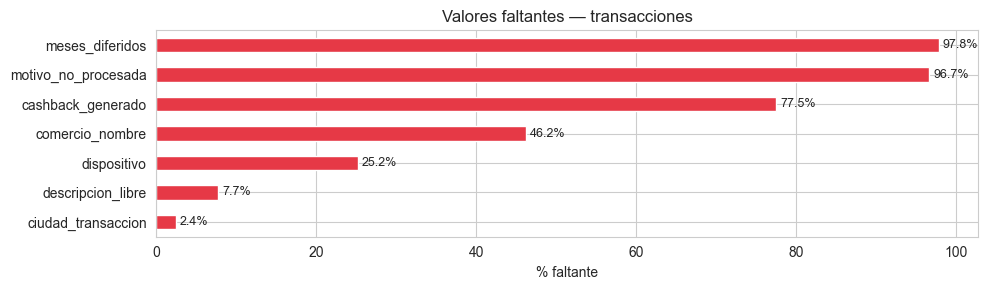

🔍 motivo_no_procesada sin null en estatus≠no_procesada: 0
🔍 motivo_no_procesada null en estatus=no_procesada: 0
🔍 cashback_generado en usuarios NO Hey Pro: 0


In [71]:
# 3.C.2 Missing — aquí también muchos nulls son semánticos
reporte_missing(df_transacciones, 'transacciones')

# Coherencia: motivo_no_procesada solo cuando estatus = 'no_procesada'
no_proc = df_transacciones['estatus'] == 'no_procesada'
print(f'🔍 motivo_no_procesada sin null en estatus≠no_procesada: '
      f'{df_transacciones.loc[~no_proc, "motivo_no_procesada"].notna().sum():,}')
print(f'🔍 motivo_no_procesada null en estatus=no_procesada: '
      f'{df_transacciones.loc[no_proc, "motivo_no_procesada"].isna().sum():,}')

# cashback_generado solo en compras completadas y Hey Pro (validar contra clientes)
hey_pro_users = set(df_clientes.loc[df_clientes['es_hey_pro'], 'user_id'])
cashback_no_pro = df_transacciones[
    df_transacciones['cashback_generado'].notna() &
    ~df_transacciones['user_id'].isin(hey_pro_users)
]
print(f'🔍 cashback_generado en usuarios NO Hey Pro: {len(cashback_no_pro):,}')

In [72]:
# 3.C.3 Duplicados
reporte_duplicados(df_transacciones, 'transacciones', key_cols=['transaccion_id'])

# Integridad referencial
huerf_user = ~df_transacciones['user_id'].isin(df_clientes['user_id'])
huerf_prod = ~df_transacciones['producto_id'].isin(df_productos['producto_id'])
print(f'\n🔗 Transacciones con user_id no en clientes:    {huerf_user.sum():,}')
print(f'🔗 Transacciones con producto_id no en productos: {huerf_prod.sum():,}')

🔁 transacciones: 0 filas completamente duplicadas (0.00%)
   Duplicados por ['transaccion_id']: 171
   Ejemplos:


,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,estatus,motivo_no_procesada,intento_numero,meses_diferidos,cashback_generado,descripcion_libre,hora_del_dia,dia_semana,es_internacional,dispositivo,patron_uso_atipico,es_dato_sintetico
3689,TXN-0000003652,USR-00065,PRD-00000169,2025-11-06 09:29:35,compra,app_android,569.5100,GamerPass,servicios_digitales,Tlaquepaque,completada,NaN,1,NaN,5.7000,ret cajero auto,9,Thursday,False,app_android,False,True
3690,TXN-0000003652,USR-00065,PRD-00000169,2025-11-06 09:30:01,compra,app_android,569.5100,GamerPass,servicios_digitales,Tlaquepaque,completada,NaN,1,NaN,5.7000,ret cajero auto,9,Thursday,False,app_android,False,True
9520,TXN-0000009524,USR-00178,PRD-00000444,2025-08-12 07:12:31,pago_servicio,app_huawei,"2,374.2500",CFE Digital,gobierno,San Pedro Garza García,no_procesada,cuenta_destino_invalida,3,NaN,NaN,cobro membresia,7,Tuesday,False,app_huawei,False,True
9521,TXN-0000009524,USR-00178,PRD-00000444,2025-08-12 07:13:19,pago_servicio,app_huawei,"2,374.2500",CFE Digital,gobierno,San Pedro Garza García,no_procesada,cuenta_destino_invalida,3,NaN,NaN,cobro membresia,7,Tuesday,False,app_huawei,False,True
11039,TXN-0000011032,USR-00208,PRD-00000514,2025-10-17 13:41:47,transf_salida,app_ios,"24,390.0000",NaN,transferencia,Acuña,completada,NaN,1,NaN,NaN,DEP EFECTIVO,13,Friday,False,app_ios,False,True
11040,TXN-0000011032,USR-00208,PRD-00000514,2025-10-17 13:41:59,transf_salida,app_ios,"24,390.0000",NaN,transferencia,Acuña,completada,NaN,1,NaN,NaN,DEP EFECTIVO,13,Friday,False,app_ios,False,True



🔗 Transacciones con user_id no en clientes:    0
🔗 Transacciones con producto_id no en productos: 0


In [73]:
# 3.C.4 Calidad categórica
cat_tx = ['tipo_operacion', 'canal', 'categoria_mcc', 'estatus', 'motivo_no_procesada', 'dia_semana', 'dispositivo', 'ciudad_transaccion']
diagnostico_categoricas(df_transacciones, cat_tx, 'transacciones')

for c in ['tipo_operacion', 'canal', 'categoria_mcc', 'estatus', 'motivo_no_procesada']:
    print(f'\n— {c} —')
    print(df_transacciones[c].value_counts(dropna=False).head(20).to_string())


🔎 Diagnóstico de calidad en categóricas — transacciones
  ✅ tipo_operacion: 12 valores únicos. OK
  ✅ canal: 9 valores únicos. OK
  ✅ categoria_mcc: 14 valores únicos. OK
  ✅ estatus: 4 valores únicos. OK
  ✅ motivo_no_procesada: 8 valores únicos. OK
  ✅ dia_semana: 7 valores únicos. OK
  ✅ dispositivo: 3 valores únicos. OK
  ✅ ciudad_transaccion: 93 valores únicos. OK

— tipo_operacion —
tipo_operacion
compra               319524
transf_entrada        92167
transf_salida         90116
cargo_recurrente      67249
pago_credito          51651
pago_servicio         48562
abono_inversion       41769
retiro_cajero         38989
deposito_oxxo         23152
cashback              14226
retiro_inversion      11822
deposito_farmacia      3157

— canal —
canal
app_ios            268313
app_android        226431
pos_fisico         110411
app_huawei         105577
cajero_banregio     26526
codi                26354
oxxo                23152
cajero_externo      12463
farmacia_ahorro      3157

— ca

In [74]:
# Validación de catálogos contra diccionario
esperados_tx = {
    'tipo_operacion': {'compra', 'transf_salida', 'transf_entrada', 'retiro_cajero', 'deposito_oxxo',
                       'deposito_farmacia', 'pago_servicio', 'pago_credito', 'abono_inversion',
                       'retiro_inversion', 'cargo_recurrente', 'cashback', 'devolucion'},
    'canal': {'app_ios', 'app_android', 'app_huawei', 'cajero_banregio', 'cajero_externo',
              'pos_fisico', 'codi', 'oxxo', 'farmacia_ahorro'},
    'categoria_mcc': {'supermercado', 'restaurante', 'delivery', 'entretenimiento', 'transporte',
                      'servicios_digitales', 'salud', 'educacion', 'ropa_accesorios', 'tecnologia',
                      'viajes', 'gobierno', 'hogar', 'transferencia'},
    'estatus': {'completada', 'no_procesada', 'en_disputa', 'revertida'},
    'motivo_no_procesada': {'saldo_insuficiente', 'tarjeta_bloqueada', 'limite_excedido',
                             'datos_invalidos', 'timeout_banco', 'codigo_incorrecto',
                             'cuenta_destino_invalida', 'monto_excede_limite_diario'},
    'dia_semana': {'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'},
}
print('🔍 Validación de catálogos (transacciones):')
for col, ok in esperados_tx.items():
    actual = set(df_transacciones[col].dropna().unique())
    extras = actual - ok
    flag = '⚠️' if extras else '✅'
    print(f'  {flag} {col}: extras={extras if extras else "—"}')

🔍 Validación de catálogos (transacciones):
  ✅ tipo_operacion: extras=—
  ✅ canal: extras=—
  ⚠️ categoria_mcc: extras={'retiro_cajero'}
  ✅ estatus: extras=—
  ✅ motivo_no_procesada: extras=—
  ✅ dia_semana: extras=—


In [75]:
# 3.C.5 Numéricas
num_tx = ['monto', 'intento_numero', 'meses_diferidos', 'cashback_generado', 'hora_del_dia']
perfil_tx = perfil_numericas(df_transacciones, num_tx)
display(perfil_tx)

# Validación: cashback_generado ≈ 1% del monto cuando aplica
cb = df_transacciones[df_transacciones['cashback_generado'].notna()].copy()
if len(cb):
    cb['cb_implicito'] = cb['cashback_generado'] / cb['monto']
    print(f'\n🔍 Ratio cashback/monto cuando aplica:')
    print(cb['cb_implicito'].describe().round(4).to_string())

,variable,min,p25,mediana,media,p75,max,std,skew,kurtosis,pct_outliers_iqr,distribucion
0,monto,5.0100,540.0000,"1,740.0000","6,108.4960","7,030.9375","79,511.3000","9,885.3087",2.6991,8.3900,12.4700,log-normal / sesgo derecho fuerte
1,intento_numero,1.0000,1.0000,1.0000,1.0331,1.0000,3.0000,0.2322,7.4705,56.8502,2.2100,log-normal / sesgo derecho fuerte
2,meses_diferidos,3.0000,6.0000,9.0000,10.7846,12.0000,24.0000,7.2024,0.9095,-0.4563,19.7200,sesgo derecho moderado
3,cashback_generado,0.1200,3.5600,6.9300,14.7853,17.2400,764.2900,24.6337,6.3061,85.4774,6.2400,log-normal / sesgo derecho fuerte
4,hora_del_dia,0.0000,6.0000,11.0000,11.4427,17.0000,23.0000,6.7615,0.0221,-1.1249,0.0000,aprox. uniforme / bimodal



🔍 Ratio cashback/monto cuando aplica:
count   180,638.0000
mean          0.0100
std           0.0000
min           0.0096
25%           0.0100
50%           0.0100
75%           0.0100
max           0.0104


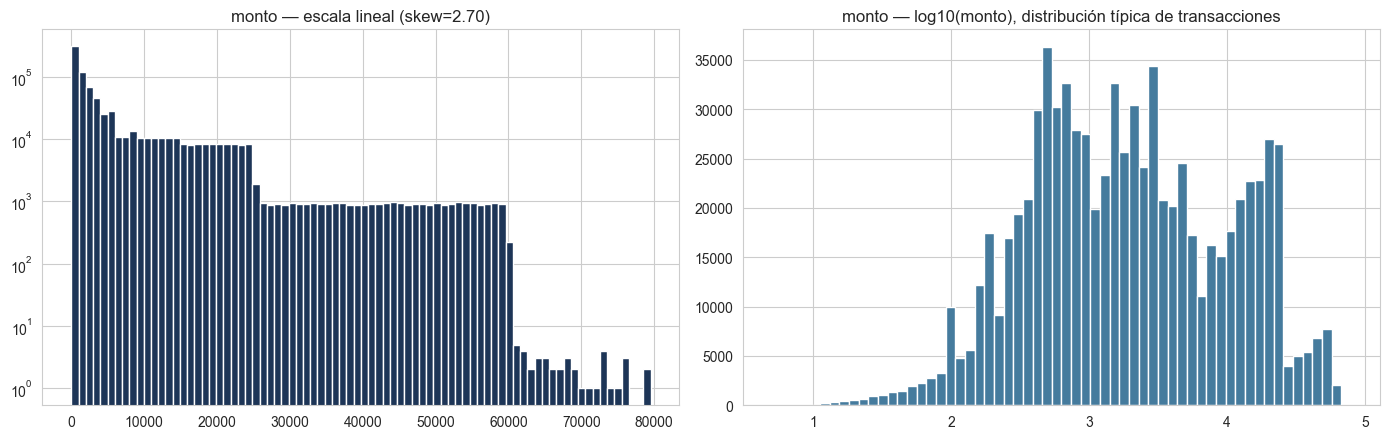

In [76]:
# 3.C.6 Visualizaciones
# 6a · Distribución de monto en log-scale (mucho sesgo derecho)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(df_transacciones['monto'], bins=80, color='#1D3557', edgecolor='white')
axes[0].set_title(f'monto — escala lineal (skew={df_transacciones["monto"].skew():.2f})')
axes[0].set_yscale('log')
axes[1].hist(np.log10(df_transacciones['monto'].clip(lower=1)), bins=60, color='#457B9D', edgecolor='white')
axes[1].set_title('monto — log10(monto), distribución típica de transacciones')
plt.tight_layout()
plt.show()

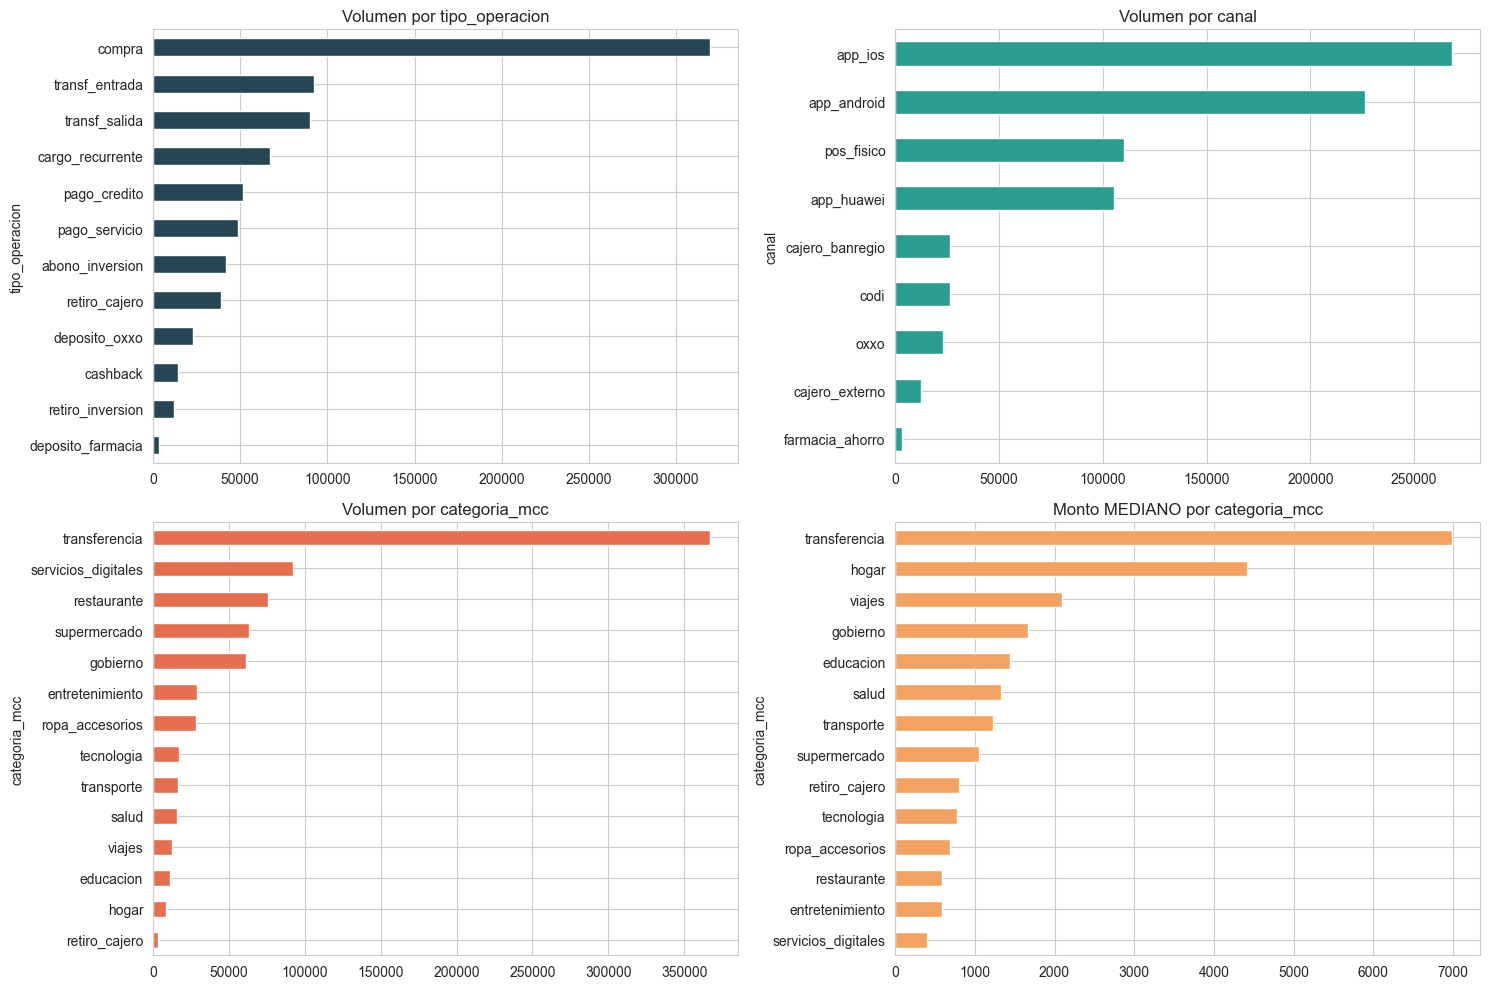

In [77]:
# 6b · Volumen y monto por tipo_operacion / canal / mcc
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df_transacciones['tipo_operacion'].value_counts().plot(kind='barh', ax=axes[0, 0], color='#264653')
axes[0, 0].set_title('Volumen por tipo_operacion')
axes[0, 0].invert_yaxis()

df_transacciones['canal'].value_counts().plot(kind='barh', ax=axes[0, 1], color='#2A9D8F')
axes[0, 1].set_title('Volumen por canal')
axes[0, 1].invert_yaxis()

df_transacciones['categoria_mcc'].value_counts().plot(kind='barh', ax=axes[1, 0], color='#E76F51')
axes[1, 0].set_title('Volumen por categoria_mcc')
axes[1, 0].invert_yaxis()

df_transacciones.groupby('categoria_mcc')['monto'].median().sort_values().plot(
    kind='barh', ax=axes[1, 1], color='#F4A261'
)
axes[1, 1].set_title('Monto MEDIANO por categoria_mcc')
plt.tight_layout()
plt.show()

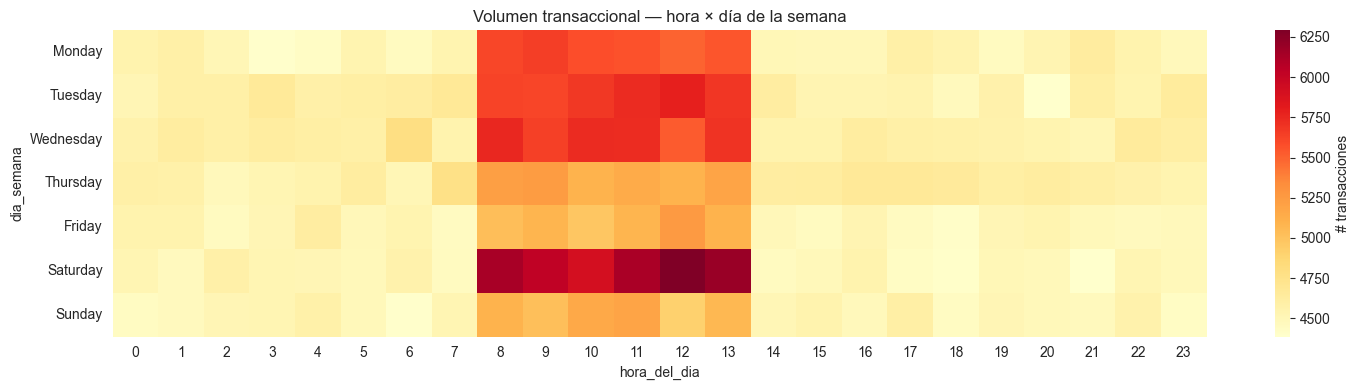

In [78]:
# 6c · Patrón temporal: hora_del_dia × dia_semana → heatmap
dia_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivote = df_transacciones.pivot_table(
    index='dia_semana', columns='hora_del_dia', values='transaccion_id', aggfunc='count'
).reindex(dia_orden)

fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(pivote, cmap='YlOrRd', ax=ax, cbar_kws={'label': '# transacciones'})
ax.set_title('Volumen transaccional — hora × día de la semana')
plt.tight_layout()
plt.show()

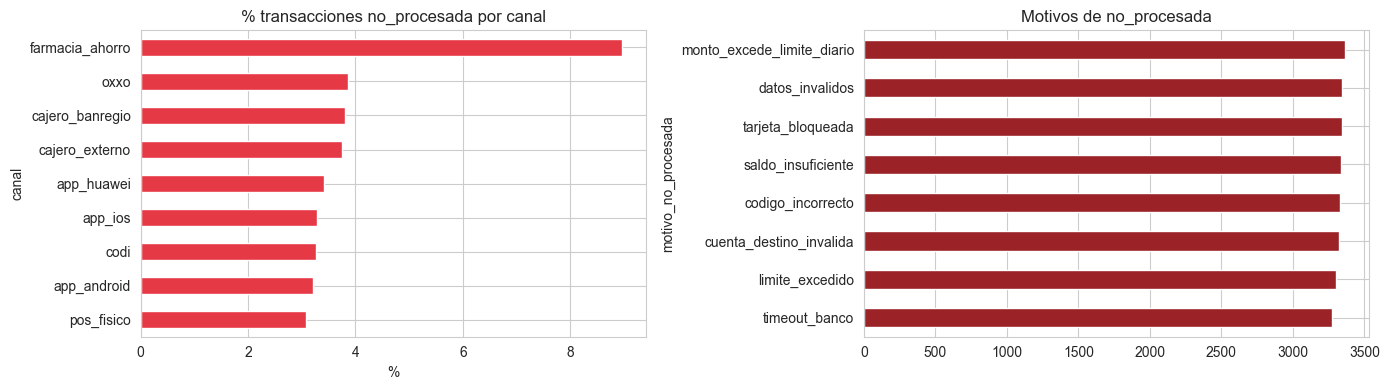

In [79]:
# 6d · Tasa de fallo por canal y por motivo
tasa_fallo_canal = (df_transacciones.assign(falla=lambda d: d['estatus'] == 'no_procesada')
                    .groupby('canal')['falla'].mean().sort_values(ascending=False) * 100)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tasa_fallo_canal.plot(kind='barh', ax=axes[0], color='#E63946')
axes[0].set_title('% transacciones no_procesada por canal')
axes[0].set_xlabel('%')
axes[0].invert_yaxis()

df_transacciones['motivo_no_procesada'].value_counts().plot(kind='barh', ax=axes[1], color='#9B2226')
axes[1].set_title('Motivos de no_procesada')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

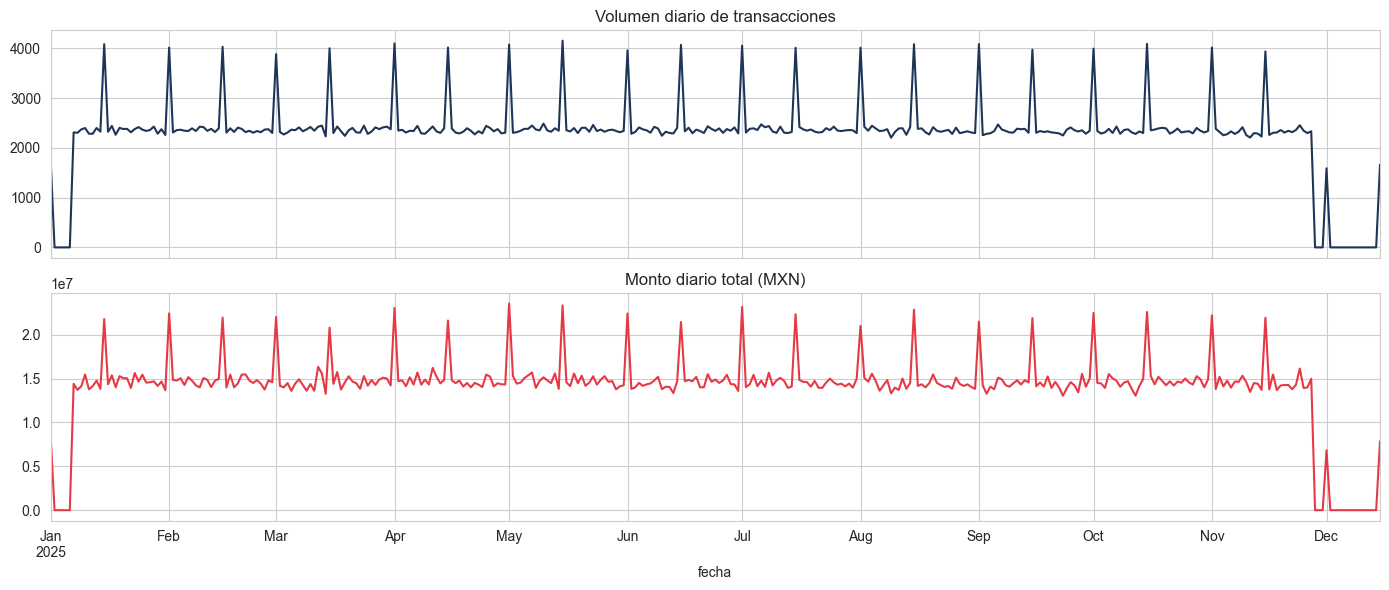

In [80]:
# 6e · Serie temporal — volumen y monto agregado por día
df_tx_t = df_transacciones.set_index('fecha_hora')
diario = df_tx_t.resample('D').agg(volumen=('transaccion_id', 'count'),
                                    monto=('monto', 'sum'))
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
diario['volumen'].plot(ax=axes[0], color='#1D3557')
axes[0].set_title('Volumen diario de transacciones')
diario['monto'].plot(ax=axes[1], color='#E63946')
axes[1].set_title('Monto diario total (MXN)')
axes[1].set_xlabel('fecha')
plt.tight_layout()
plt.show()

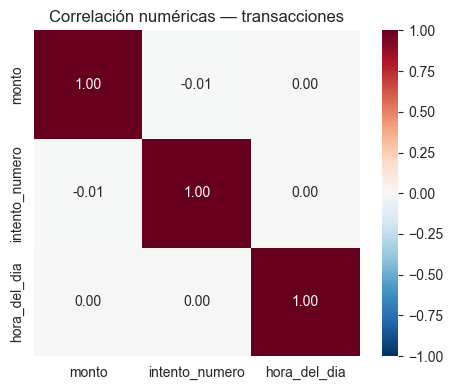

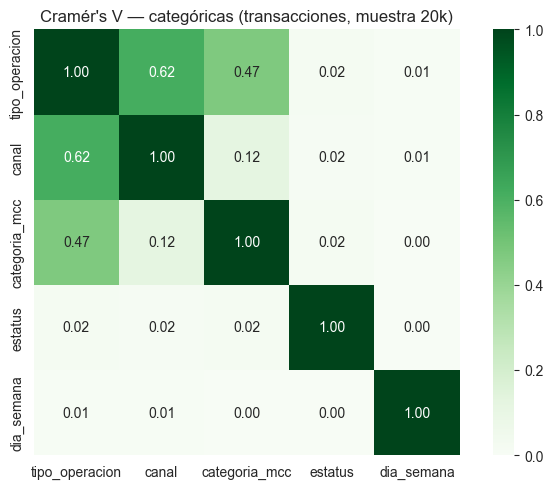

In [81]:
# 3.C.7 Correlaciones — transacciones
# Numéricas: poco que correlacionar (la riqueza de tx es categórica)
num_tx_corr = ['monto', 'intento_numero', 'hora_del_dia']
corr_tx = df_transacciones[num_tx_corr].corr(method='spearman')
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_tx, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlación numéricas — transacciones')
plt.tight_layout()
plt.show()

# Cramér's V entre categóricas (sobre muestra para velocidad)
muestra_tx = df_transacciones.sample(n=min(20000, len(df_transacciones)), random_state=42)
cat_tx_corr = ['tipo_operacion', 'canal', 'categoria_mcc', 'estatus', 'dia_semana']
vmat_tx = matriz_cramers_v(muestra_tx, cat_tx_corr)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(vmat_tx, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("Cramér's V — categóricas (transacciones, muestra 20k)")
plt.tight_layout()
plt.show()

---
## 4. Resumen ejecutivo

Esta celda final genera un dict con los hallazgos clave para anexarlo al pitch.

In [82]:
resumen = {
    'clientes': {
        'n_filas': len(df_clientes),
        'n_columnas': df_clientes.shape[1],
        'pct_null_total': round(100 * df_clientes.isna().sum().sum() / df_clientes.size, 2),
        'duplicados_user_id': int(df_clientes.duplicated(subset=['user_id']).sum()),
        'mediana_edad': float(df_clientes['edad'].median()),
        'mediana_ingreso': float(df_clientes['ingreso_mensual_mxn'].median()),
        'pct_hey_pro': round(100 * df_clientes['es_hey_pro'].mean(), 1),
        'pct_patron_atipico': round(100 * df_clientes['patron_uso_atipico'].mean(), 1),
    },
    'productos': {
        'n_filas': len(df_productos),
        'productos_por_usuario_mediana': float(df_productos.groupby('user_id').size().median()),
        'tipo_producto_top': df_productos['tipo_producto'].value_counts().head(3).to_dict(),
    },
    'transacciones': {
        'n_filas': len(df_transacciones),
        'rango_fechas': [str(df_transacciones['fecha_hora'].min()),
                          str(df_transacciones['fecha_hora'].max())],
        'pct_no_procesada': round(100 * (df_transacciones['estatus'] == 'no_procesada').mean(), 2),
        'monto_mediano': float(df_transacciones['monto'].median()),
        'usuarios_activos': df_transacciones['user_id'].nunique(),
    },
}

import json
print(json.dumps(resumen, indent=2, default=str))

{
  "clientes": {
    "n_filas": 15025,
    "n_columnas": 22,
    "pct_null_total": 0.49,
    "duplicados_user_id": 0,
    "mediana_edad": 36.0,
    "mediana_ingreso": 24000.0,
    "pct_hey_pro": 48.9,
    "pct_patron_atipico": 5.1
  },
  "productos": {
    "n_filas": 38909,
    "productos_por_usuario_mediana": 3.0,
    "tipo_producto_top": {
      "cuenta_debito": 15025,
      "tarjeta_credito_hey": 7565,
      "inversion_hey": 4474
    }
  },
  "transacciones": {
    "n_filas": 802384,
    "rango_fechas": [
      "2025-01-01 08:00:09",
      "2025-12-15 13:59:36"
    ],
    "pct_no_procesada": 3.32,
    "monto_mediano": 1740.0,
    "usuarios_activos": 15025
  }
}


---
### Siguientes pasos sugeridos (para el reto)

Con los hallazgos de este EDA, las decisiones de feature engineering quedan claras:
- Variables a estandarizar/log-transform: `monto`, `ingreso_mensual_mxn`, `saldo_actual`, `limite_credito` (todos con sesgo derecho fuerte).
- Categóricas con baja cardinalidad → one-hot directo.
- `ciudad`/`estado` → considerar target encoding o agrupación por top-N.
- Los nulls semánticos en productos/transacciones **no se imputan** — son información (un null en `limite_credito` significa 'no es producto de crédito').
- Outliers en `monto` no se eliminan: son señal (transacciones grandes son las más interesantes para un trigger de inversión).